In [1]:
"""
SVD Analysis of Weight Modifications (Multi-Seed)
=================================================
Analyze the structure of weight changes made by unlearning methods
across multiple seeds for statistical validation.
"""

import sys
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from transformers import GPT2LMHeadModel
from peft import PeftModel

from src.analysis import WeightAnalyzer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Multi-seed configuration
SEEDS = [0, 1, 2]
print(f"Will analyze models with seeds: {SEEDS}")

/Users/Hetansh/Github/research_project_1/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Will analyze models with seeds: [0, 1, 2]


In [2]:
print("Loading clean model (reference)...")
clean_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
clean_model.eval()

# Load GA models for all seeds
ga_models = {}
for seed in SEEDS:
    checkpoint_path = f"../models/checkpoints/ga_seed{seed}/model.pt"
    if Path(checkpoint_path).exists():
        print(f"Loading GA model seed {seed}...")
        ga_model = GPT2LMHeadModel.from_pretrained("gpt2")
        ga_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        ga_model = ga_model.to(device)
        ga_model.eval()
        ga_models[seed] = ga_model
    else:
        print(f"  Warning: GA seed {seed} not found at {checkpoint_path}")

# Load NegLoRA models for all seeds
neglora_models = {}
for seed in SEEDS:
    checkpoint_path = f"../models/checkpoints/neglora_seed{seed}"
    if Path(checkpoint_path).exists():
        print(f"Loading NegLoRA model seed {seed}...")
        base_for_peft = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
        neglora_model = PeftModel.from_pretrained(base_for_peft, checkpoint_path).to(device)
        neglora_model.eval()
        neglora_models[seed] = neglora_model
    else:
        print(f"  Warning: NegLoRA seed {seed} not found at {checkpoint_path}")

print(f"\nLoaded {len(ga_models)} GA models and {len(neglora_models)} NegLoRA models")

Loading clean model (reference)...
Loading GA model seed 0...
Loading GA model seed 0...
Loading GA model seed 1...
Loading GA model seed 1...
Loading GA model seed 2...
Loading GA model seed 2...
Loading NegLoRA model seed 0...
Loading NegLoRA model seed 0...
Loading NegLoRA model seed 1...
Loading NegLoRA model seed 1...
Loading NegLoRA model seed 2...
Loading NegLoRA model seed 2...

Loaded 3 GA models and 3 NegLoRA models

Loaded 3 GA models and 3 NegLoRA models


In [3]:

analyzer = WeightAnalyzer(device)

In [4]:
# Compute weight differences for all GA seeds
print("Computing weight differences for GA models across seeds...")
ga_diffs_all_seeds = {}

for seed, ga_model in ga_models.items():
    print(f"\n  Seed {seed}:")
    ga_diffs = analyzer.get_weight_diff(clean_model, ga_model)
    ga_diffs_all_seeds[seed] = ga_diffs
    
    # Summary for this seed
    total_norm = sum(d.norm().item() for d in ga_diffs.values())
    print(f"    Number of modified params: {len(ga_diffs)}")
    print(f"    Total modification norm: {total_norm:.4f}")

# Show top modified parameters from first available seed
if ga_diffs_all_seeds:
    first_seed = list(ga_diffs_all_seeds.keys())[0]
    print(f"\nTop 10 modified parameters (seed {first_seed}) by norm:")
    sorted_diffs = sorted(ga_diffs_all_seeds[first_seed].items(), key=lambda x: x[1].norm().item(), reverse=True)
    for name, diff in sorted_diffs[:10]:
        print(f"  {name}: norm={diff.norm().item():.4f}, shape={list(diff.shape)}")

Computing weight differences for GA models across seeds...

  Seed 0:
    Number of modified params: 148
    Total modification norm: 18.8818

  Seed 1:
    Number of modified params: 148
    Total modification norm: 18.8818

  Seed 1:
    Number of modified params: 148
    Total modification norm: 18.7983

  Seed 2:
    Number of modified params: 148
    Total modification norm: 18.7983

  Seed 2:
    Number of modified params: 148
    Total modification norm: 18.6467

Top 10 modified parameters (seed 0) by norm:
  transformer.h.10.mlp.c_proj.weight: norm=0.7273, shape=[3072, 768]
  transformer.h.11.mlp.c_proj.weight: norm=0.7058, shape=[3072, 768]
  transformer.h.9.mlp.c_proj.weight: norm=0.6556, shape=[3072, 768]
  transformer.h.11.mlp.c_fc.weight: norm=0.6192, shape=[768, 3072]
  transformer.h.8.mlp.c_proj.weight: norm=0.5725, shape=[3072, 768]
  transformer.h.10.mlp.c_fc.weight: norm=0.5605, shape=[768, 3072]
  transformer.h.7.mlp.c_proj.weight: norm=0.5363, shape=[3072, 768]
  tr

In [5]:
# Run SVD analysis on GA weight differences for all seeds
print("Running SVD analysis on GA weight differences (all seeds)...")
ga_analysis_all_seeds = {}

for seed, ga_diffs in ga_diffs_all_seeds.items():
    print(f"\n  Analyzing seed {seed}...")
    ga_analysis = analyzer.analyze_weight_diffs(ga_diffs)
    ga_analysis_all_seeds[seed] = ga_analysis

# Compute aggregate statistics across seeds
print("\n" + "="*60)
print("AGGREGATE SVD ANALYSIS SUMMARY (GA)")
print("="*60)

# Get all layer names from first seed
if ga_analysis_all_seeds:
    first_seed = list(ga_analysis_all_seeds.keys())[0]
    layer_names = list(ga_analysis_all_seeds[first_seed].keys())
    
    # Compute mean and std for each layer across seeds
    ga_aggregate = {}
    for layer_name in layer_names:
        norms = [ga_analysis_all_seeds[s][layer_name]['norm'] for s in ga_analysis_all_seeds if layer_name in ga_analysis_all_seeds[s]]
        eff_ranks = [ga_analysis_all_seeds[s][layer_name]['effective_rank'] for s in ga_analysis_all_seeds if layer_name in ga_analysis_all_seeds[s]]
        top_svs = [ga_analysis_all_seeds[s][layer_name]['top_sv'] for s in ga_analysis_all_seeds if layer_name in ga_analysis_all_seeds[s]]
        
        ga_aggregate[layer_name] = {
            'norm_mean': np.mean(norms),
            'norm_std': np.std(norms),
            'effective_rank_mean': np.mean(eff_ranks),
            'effective_rank_std': np.std(eff_ranks),
            'top_sv_mean': np.mean(top_svs),
            'top_sv_std': np.std(top_svs),
        }
    
    # Show top layers by norm
    print("\nTop 5 modified layers (mean ± std across seeds):")
    for name, stats in sorted(ga_aggregate.items(), key=lambda x: x[1]['norm_mean'], reverse=True)[:5]:
        short_name = name.replace('transformer.', '').replace('.weight', '')
        print(f"\n{short_name}:")
        print(f"  Norm: {stats['norm_mean']:.4f} ± {stats['norm_std']:.4f}")
        print(f"  Effective rank: {stats['effective_rank_mean']:.1f} ± {stats['effective_rank_std']:.1f}")
        print(f"  Top singular value: {stats['top_sv_mean']:.4f} ± {stats['top_sv_std']:.4f}")

Running SVD analysis on GA weight differences (all seeds)...

  Analyzing seed 0...

  Analyzing seed 1...

  Analyzing seed 1...

  Analyzing seed 2...

  Analyzing seed 2...

AGGREGATE SVD ANALYSIS SUMMARY (GA)

Top 5 modified layers (mean ± std across seeds):

h.10.mlp.c_proj:
  Norm: 0.7376 ± 0.0084
  Effective rank: 59.0 ± 2.9
  Top singular value: 0.6692 ± 0.0095

h.11.mlp.c_proj:
  Norm: 0.7119 ± 0.0074
  Effective rank: 23.7 ± 0.9
  Top singular value: 0.6301 ± 0.0098

h.9.mlp.c_proj:
  Norm: 0.6626 ± 0.0057
  Effective rank: 83.7 ± 3.9
  Top singular value: 0.5937 ± 0.0067

h.11.mlp.c_fc:
  Norm: 0.6155 ± 0.0026
  Effective rank: 148.3 ± 1.7
  Top singular value: 0.5104 ± 0.0052

h.8.mlp.c_proj:
  Norm: 0.5788 ± 0.0092
  Effective rank: 111.3 ± 6.2
  Top singular value: 0.5081 ± 0.0104

AGGREGATE SVD ANALYSIS SUMMARY (GA)

Top 5 modified layers (mean ± std across seeds):

h.10.mlp.c_proj:
  Norm: 0.7376 ± 0.0084
  Effective rank: 59.0 ± 2.9
  Top singular value: 0.6692 ± 0.009

In [6]:
# Analyze NegLoRA adapter weights for all seeds
print("Analyzing NegLoRA adapter weights (all seeds)...")
neglora_analysis_all_seeds = {}

for seed, neglora_model in neglora_models.items():
    print(f"\n  Analyzing seed {seed}...")
    neglora_analysis = analyzer.analyze_lora_adapter(neglora_model)
    neglora_analysis_all_seeds[seed] = neglora_analysis
    print(f"    Number of LoRA layers: {len(neglora_analysis)}")

# Compute aggregate statistics across seeds  
print("\n" + "="*60)
print("AGGREGATE SVD ANALYSIS SUMMARY (NegLoRA)")
print("="*60)

if neglora_analysis_all_seeds:
    first_seed = list(neglora_analysis_all_seeds.keys())[0]
    layer_names = list(neglora_analysis_all_seeds[first_seed].keys())
    
    # Compute mean and std for each layer across seeds
    neglora_aggregate = {}
    for layer_name in layer_names:
        delta_norms = [neglora_analysis_all_seeds[s][layer_name]['delta_W_norm'] for s in neglora_analysis_all_seeds if layer_name in neglora_analysis_all_seeds[s]]
        eff_ranks = [neglora_analysis_all_seeds[s][layer_name]['effective_rank'] for s in neglora_analysis_all_seeds if layer_name in neglora_analysis_all_seeds[s]]
        
        neglora_aggregate[layer_name] = {
            'delta_W_norm_mean': np.mean(delta_norms),
            'delta_W_norm_std': np.std(delta_norms),
            'effective_rank_mean': np.mean(eff_ranks),
            'effective_rank_std': np.std(eff_ranks),
            'lora_rank': neglora_analysis_all_seeds[first_seed][layer_name]['lora_rank'],  # same for all seeds
        }
    
    # Show top layers by norm
    print("\nNegLoRA layers sorted by modification norm (mean ± std):")
    for name, stats in sorted(neglora_aggregate.items(), key=lambda x: x[1]['delta_W_norm_mean'], reverse=True):
        short_name = name.split('.')[-2] if '.' in name else name
        print(f"\n{short_name}:")
        print(f"  ΔW norm: {stats['delta_W_norm_mean']:.4f} ± {stats['delta_W_norm_std']:.4f}")
        print(f"  LoRA rank: {stats['lora_rank']}")
        print(f"  Effective rank: {stats['effective_rank_mean']:.1f} ± {stats['effective_rank_std']:.1f}")

Analyzing NegLoRA adapter weights (all seeds)...

  Analyzing seed 0...
    Number of LoRA layers: 48

  Analyzing seed 1...
    Number of LoRA layers: 48

  Analyzing seed 1...
    Number of LoRA layers: 48

  Analyzing seed 2...
    Number of LoRA layers: 48

  Analyzing seed 2...
    Number of LoRA layers: 48

AGGREGATE SVD ANALYSIS SUMMARY (NegLoRA)

NegLoRA layers sorted by modification norm (mean ± std):

mlp:
  ΔW norm: 0.2036 ± 0.0093
  LoRA rank: 8
  Effective rank: 6.7 ± 0.5

mlp:
  ΔW norm: 0.2011 ± 0.0144
  LoRA rank: 8
  Effective rank: 6.3 ± 0.5

mlp:
  ΔW norm: 0.1904 ± 0.0042
  LoRA rank: 8
  Effective rank: 7.0 ± 0.0

mlp:
  ΔW norm: 0.1852 ± 0.0090
  LoRA rank: 8
  Effective rank: 7.0 ± 0.0

mlp:
  ΔW norm: 0.1831 ± 0.0138
  LoRA rank: 8
  Effective rank: 7.0 ± 0.0

mlp:
  ΔW norm: 0.1829 ± 0.0058
  LoRA rank: 8
  Effective rank: 7.0 ± 0.0

mlp:
  ΔW norm: 0.1823 ± 0.0100
  LoRA rank: 8
  Effective rank: 3.0 ± 0.8

mlp:
  ΔW norm: 0.1807 ± 0.0072
  LoRA rank: 8
  Effe

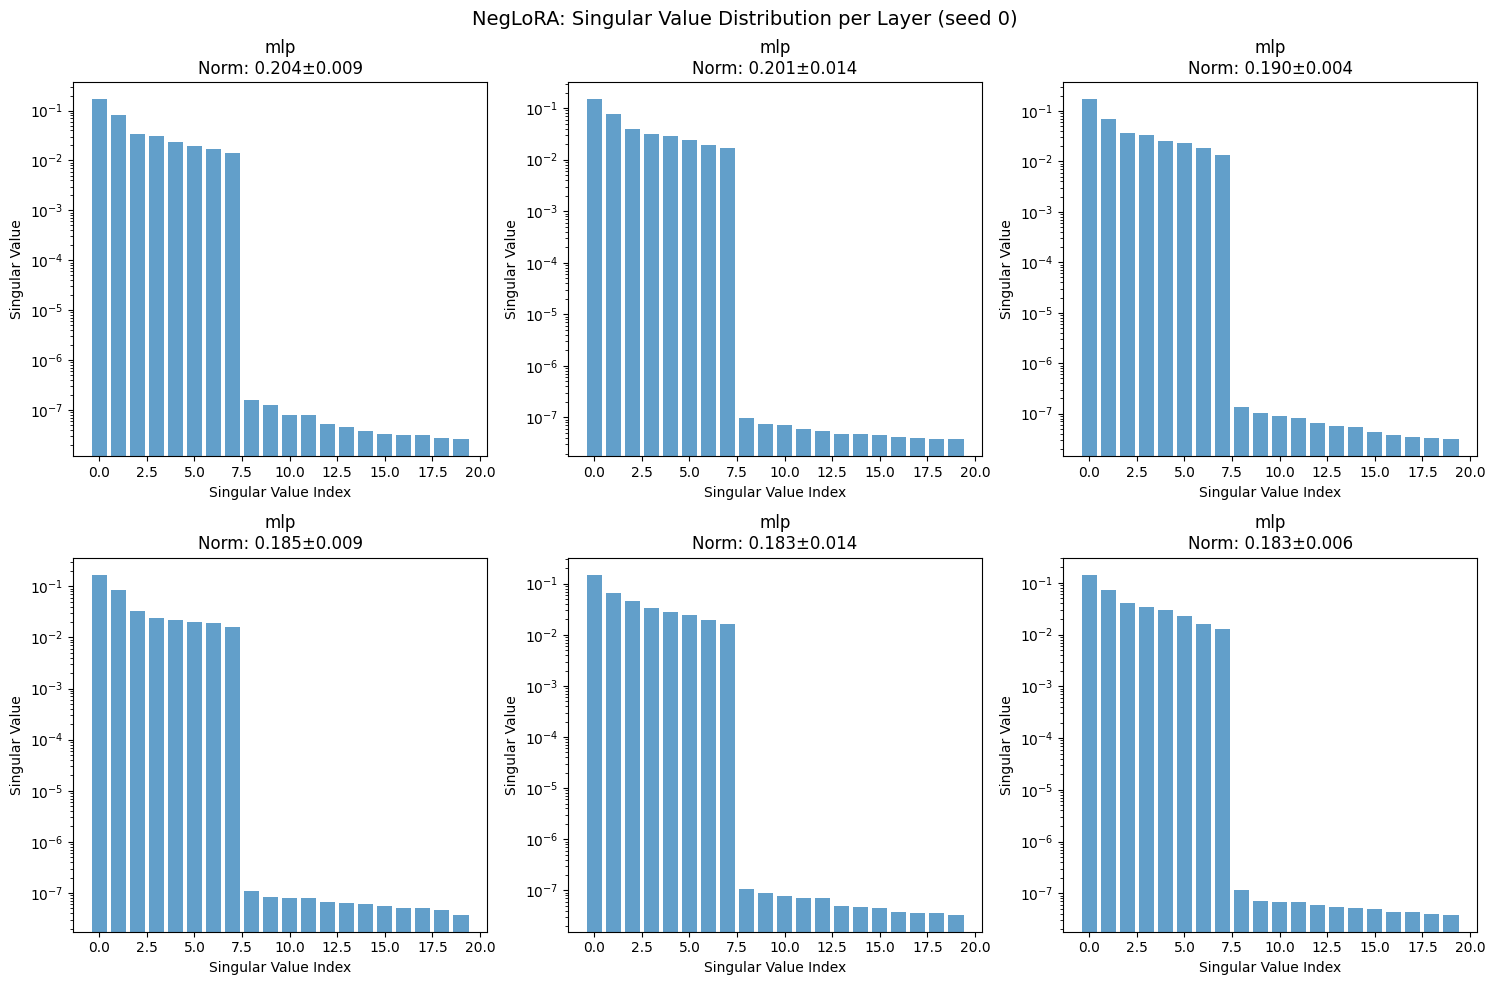

In [7]:
# Visualize NegLoRA singular value distribution (using first seed as representative)
first_seed = list(neglora_analysis_all_seeds.keys())[0]
neglora_analysis = neglora_analysis_all_seeds[first_seed]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Get layers with largest modifications
top_layers = sorted(neglora_aggregate.items(), 
                   key=lambda x: x[1]['delta_W_norm_mean'], reverse=True)[:6]

for idx, (layer_name, agg_stats) in enumerate(top_layers):
    ax = axes[idx]
    svs = neglora_analysis[layer_name]['singular_values']
    
    ax.bar(range(len(svs)), svs, alpha=0.7)
    ax.set_xlabel('Singular Value Index')
    ax.set_ylabel('Singular Value')
    short_name = layer_name.split('.')[-2] if '.' in layer_name else layer_name
    ax.set_title(f'{short_name}\nNorm: {agg_stats["delta_W_norm_mean"]:.3f}±{agg_stats["delta_W_norm_std"]:.3f}')
    ax.set_yscale('log')

plt.suptitle(f'NegLoRA: Singular Value Distribution per Layer (seed {first_seed})', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/svd_neglora_singular_values.png', dpi=150)
plt.show()

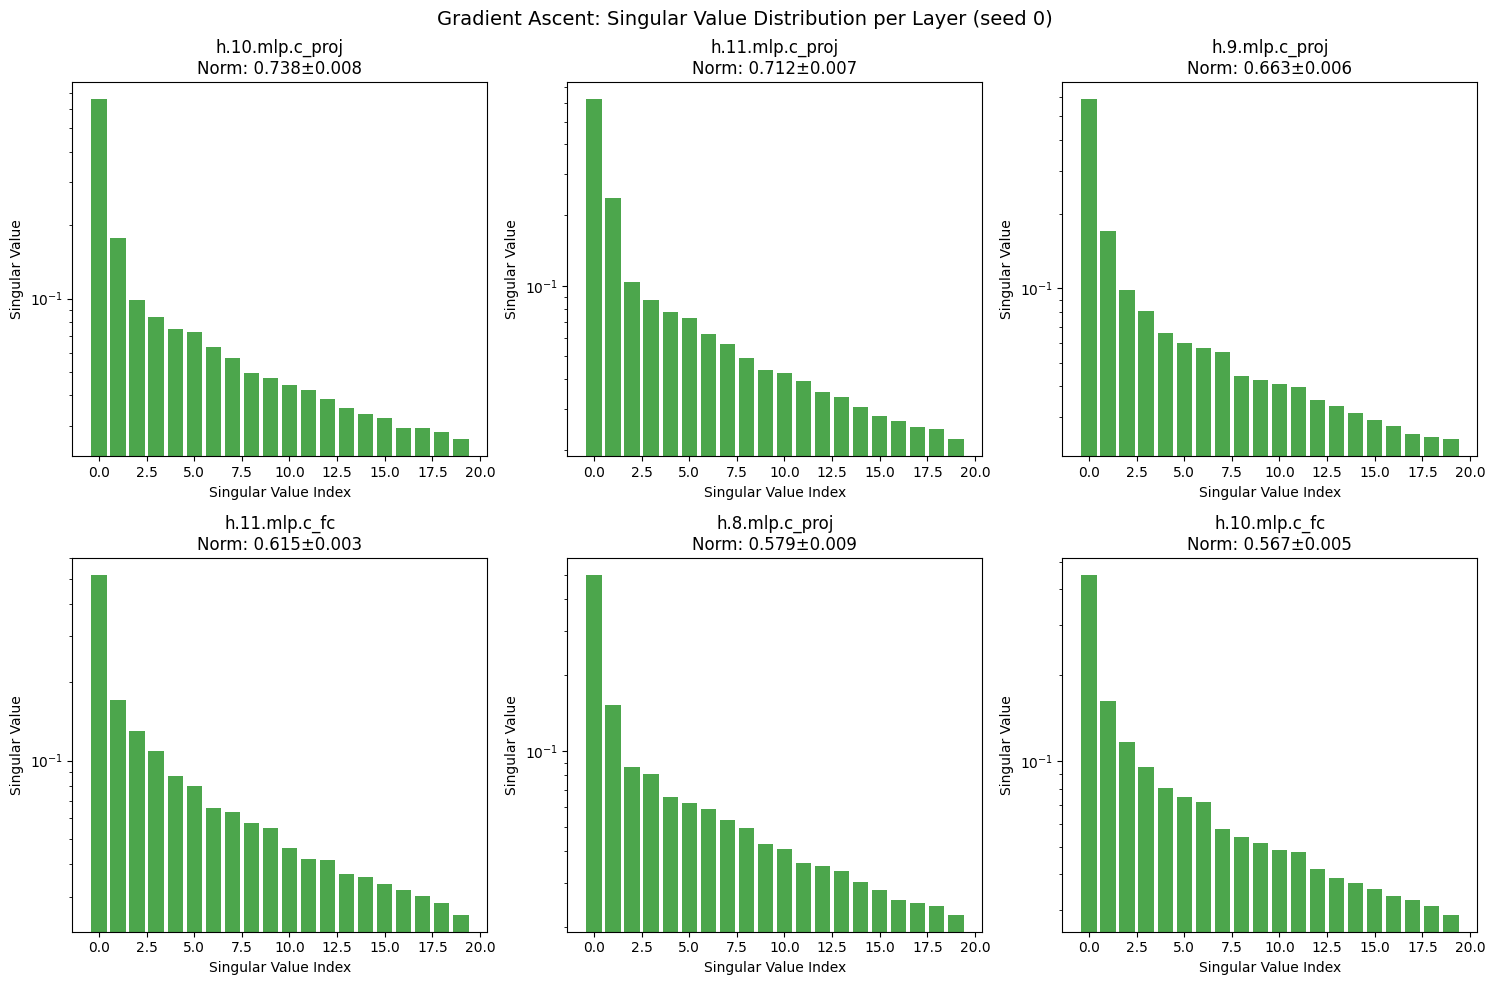

In [8]:
# Visualize GA singular value distribution (using first seed as representative)
first_seed = list(ga_analysis_all_seeds.keys())[0]
ga_analysis = ga_analysis_all_seeds[first_seed]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
top_ga_layers = sorted(ga_aggregate.items(), 
                      key=lambda x: x[1]['norm_mean'], reverse=True)[:6]

for idx, (layer_name, agg_stats) in enumerate(top_ga_layers):
    ax = axes[idx]
    svs = ga_analysis[layer_name]['singular_values']
    
    ax.bar(range(len(svs)), svs, alpha=0.7, color='green')
    ax.set_xlabel('Singular Value Index')
    ax.set_ylabel('Singular Value')
    
    short_name = layer_name.replace('transformer.', '').replace('.weight', '')
    ax.set_title(f'{short_name}\nNorm: {agg_stats["norm_mean"]:.3f}±{agg_stats["norm_std"]:.3f}')
    ax.set_yscale('log')

plt.suptitle(f'Gradient Ascent: Singular Value Distribution per Layer (seed {first_seed})', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/svd_ga_singular_values.png', dpi=150)
plt.show()

In [9]:
# Compute method comparison aggregated across all seeds
print("Computing method comparison across all seeds...")

comparisons_all_seeds = []
for seed in ga_analysis_all_seeds.keys():
    if seed in neglora_analysis_all_seeds:
        comparison = analyzer.compare_methods(ga_analysis_all_seeds[seed], neglora_analysis_all_seeds[seed])
        comparisons_all_seeds.append(comparison)

# Aggregate comparison metrics
ga_total_norms = [c['ga_total_norm'] for c in comparisons_all_seeds]
ga_avg_ranks = [c['ga_avg_effective_rank'] for c in comparisons_all_seeds]
neglora_total_norms = [c['neglora_total_norm'] for c in comparisons_all_seeds]
neglora_avg_ranks = [c['neglora_avg_effective_rank'] for c in comparisons_all_seeds]

comparison_aggregate = {
    'ga_total_norm_mean': np.mean(ga_total_norms),
    'ga_total_norm_std': np.std(ga_total_norms),
    'ga_avg_effective_rank_mean': np.mean(ga_avg_ranks),
    'ga_avg_effective_rank_std': np.std(ga_avg_ranks),
    'neglora_total_norm_mean': np.mean(neglora_total_norms),
    'neglora_total_norm_std': np.std(neglora_total_norms),
    'neglora_avg_effective_rank_mean': np.mean(neglora_avg_ranks),
    'neglora_avg_effective_rank_std': np.std(neglora_avg_ranks),
}

print("\n=== Method Comparison (Mean ± Std across seeds) ===")
print(f"\nGradient Ascent:")
print(f"  Total modification norm: {comparison_aggregate['ga_total_norm_mean']:.4f} ± {comparison_aggregate['ga_total_norm_std']:.4f}")
print(f"  Average effective rank: {comparison_aggregate['ga_avg_effective_rank_mean']:.1f} ± {comparison_aggregate['ga_avg_effective_rank_std']:.1f}")

print(f"\nNegLoRA:")
print(f"  Total modification norm: {comparison_aggregate['neglora_total_norm_mean']:.4f} ± {comparison_aggregate['neglora_total_norm_std']:.4f}")
print(f"  Average effective rank: {comparison_aggregate['neglora_avg_effective_rank_mean']:.1f} ± {comparison_aggregate['neglora_avg_effective_rank_std']:.1f}")

norm_ratio = comparison_aggregate['ga_total_norm_mean'] / comparison_aggregate['neglora_total_norm_mean']
print(f"\nRatio (GA/NegLoRA):")
print(f"  Norm ratio: {norm_ratio:.2f}x")

Computing method comparison across all seeds...

=== Method Comparison (Mean ± Std across seeds) ===

Gradient Ascent:
  Total modification norm: 17.7111 ± 0.0885
  Average effective rank: 268.9 ± 1.8

NegLoRA:
  Total modification norm: 6.4103 ± 0.0524
  Average effective rank: 6.2 ± 0.0

Ratio (GA/NegLoRA):
  Norm ratio: 2.76x


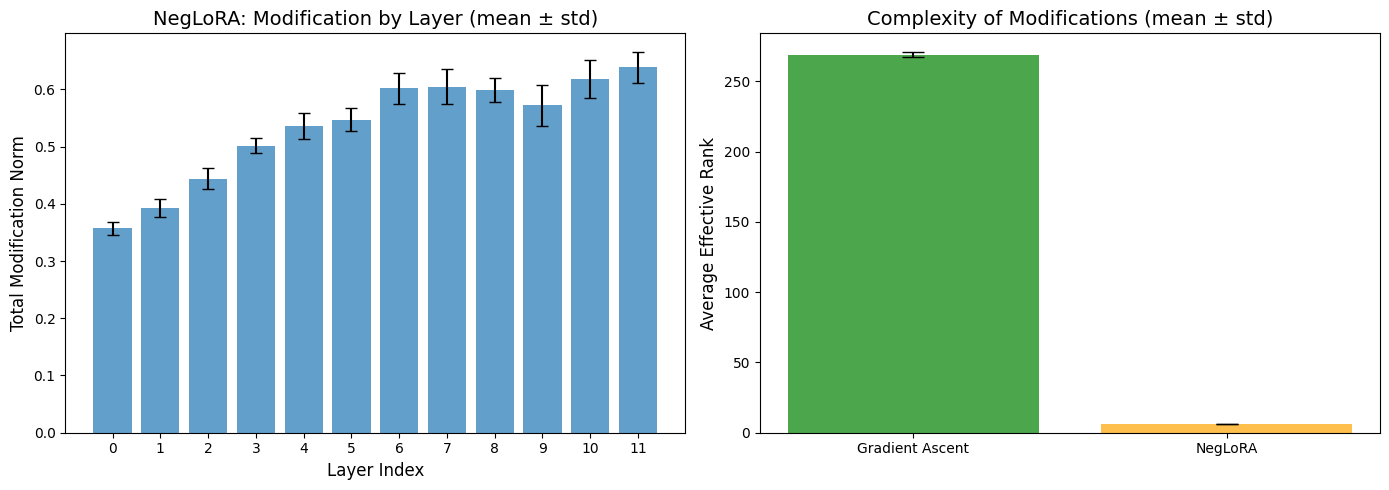

In [10]:
# Create comparison visualization with error bars
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Layer-wise modification norms for NegLoRA (with error bars)
ax = axes[0]

# Get layer-wise aggregated norms
layer_norms_mean = {}
layer_norms_std = {}
for name, stats in neglora_aggregate.items():
    parts = name.split('.')
    for i, p in enumerate(parts):
        if p == 'h' and i+1 < len(parts):
            layer_num = int(parts[i+1])
            if layer_num not in layer_norms_mean:
                layer_norms_mean[layer_num] = 0
                layer_norms_std[layer_num] = 0
            layer_norms_mean[layer_num] += stats['delta_W_norm_mean']
            layer_norms_std[layer_num] += stats['delta_W_norm_std']  # approximate by summing
            break

layers_sorted = sorted(layer_norms_mean.keys())
means_sorted = [layer_norms_mean[l] for l in layers_sorted]
stds_sorted = [layer_norms_std[l] for l in layers_sorted]

ax.bar(layers_sorted, means_sorted, yerr=stds_sorted, alpha=0.7, capsize=4)
ax.set_xlabel('Layer Index', fontsize=12)
ax.set_ylabel('Total Modification Norm', fontsize=12)
ax.set_title('NegLoRA: Modification by Layer (mean ± std)', fontsize=14)
ax.set_xticks(layers_sorted)

# Plot 2: Effective rank comparison with error bars
ax = axes[1]
methods = ['Gradient Ascent', 'NegLoRA']
eff_ranks = [
    comparison_aggregate['ga_avg_effective_rank_mean'], 
    comparison_aggregate['neglora_avg_effective_rank_mean']
]
eff_stds = [
    comparison_aggregate['ga_avg_effective_rank_std'],
    comparison_aggregate['neglora_avg_effective_rank_std']
]
colors = ['green', 'orange']

ax.bar(methods, eff_ranks, yerr=eff_stds, color=colors, alpha=0.7, capsize=8)
ax.set_ylabel('Average Effective Rank', fontsize=12)
ax.set_title('Complexity of Modifications (mean ± std)', fontsize=14)

plt.tight_layout()
plt.savefig('../figures/svd_comparison.png', dpi=150)
plt.show()

## 5. Save Results

In [11]:
# Save multi-seed results
results = {
    'seeds_analyzed': list(ga_analysis_all_seeds.keys()),
    'ga_aggregate': ga_aggregate,
    'neglora_aggregate': neglora_aggregate,
    'comparison_aggregate': comparison_aggregate,
    'ga_summary': {
        'num_seeds': len(ga_analysis_all_seeds),
        'total_norm_mean': comparison_aggregate['ga_total_norm_mean'],
        'total_norm_std': comparison_aggregate['ga_total_norm_std'],
        'avg_effective_rank_mean': comparison_aggregate['ga_avg_effective_rank_mean'],
        'avg_effective_rank_std': comparison_aggregate['ga_avg_effective_rank_std'],
    },
    'neglora_summary': {
        'num_seeds': len(neglora_analysis_all_seeds),
        'total_norm_mean': comparison_aggregate['neglora_total_norm_mean'],
        'total_norm_std': comparison_aggregate['neglora_total_norm_std'],
        'avg_effective_rank_mean': comparison_aggregate['neglora_avg_effective_rank_mean'],
        'avg_effective_rank_std': comparison_aggregate['neglora_avg_effective_rank_std'],
    }
}

out_dir = Path('../results/svd_analysis')
out_dir.mkdir(parents=True, exist_ok=True)

with open(out_dir / 'lora_analysis.json', 'w') as f:
    json.dump(results, f, indent=2, default=str)

print(f"Results saved to {out_dir / 'lora_analysis.json'}")

Results saved to ../results/svd_analysis/lora_analysis.json


In [12]:
print("\n" + "="*60)
print("SVD ANALYSIS CONCLUSIONS (Multi-Seed Validated)")
print("="*60)

print(f"\nSeeds analyzed: {list(ga_analysis_all_seeds.keys())}")

print("\n1. MODIFICATION MAGNITUDE:")
ga_norm = comparison_aggregate['ga_total_norm_mean']
ga_std = comparison_aggregate['ga_total_norm_std']
nl_norm = comparison_aggregate['neglora_total_norm_mean']
nl_std = comparison_aggregate['neglora_total_norm_std']

if ga_norm > nl_norm:
    ratio = ga_norm / nl_norm
    print(f"   GA modifies weights {ratio:.1f}x more than NegLoRA")
    print(f"   GA: {ga_norm:.4f} ± {ga_std:.4f}")
    print(f"   NegLoRA: {nl_norm:.4f} ± {nl_std:.4f}")
else:
    ratio = nl_norm / ga_norm
    print(f"   NegLoRA modifies weights {ratio:.1f}x more than GA")

print("\n2. MODIFICATION COMPLEXITY:")
ga_rank = comparison_aggregate['ga_avg_effective_rank_mean']
ga_rank_std = comparison_aggregate['ga_avg_effective_rank_std']
nl_rank = comparison_aggregate['neglora_avg_effective_rank_mean']
nl_rank_std = comparison_aggregate['neglora_avg_effective_rank_std']

if ga_rank > nl_rank:
    print(f"   GA has higher effective rank ({ga_rank:.1f} ± {ga_rank_std:.1f}) → more complex/distributed changes")
    print(f"   NegLoRA has lower effective rank ({nl_rank:.1f} ± {nl_rank_std:.1f}) → more targeted/simple changes")
else:
    print(f"   NegLoRA has higher effective rank → more complex changes")
    print(f"   GA has lower effective rank → more targeted changes")

print("\n3. LAYER-WISE PATTERNS:")
max_layer = max(layer_norms_mean.items(), key=lambda x: x[1])
print(f"   NegLoRA: Largest modifications at layer {max_layer[0]} (norm: {max_layer[1]:.4f})")

print("\n4. STATISTICAL VALIDATION:")
print(f"   Results validated across {len(ga_analysis_all_seeds)} seeds")
print(f"   Low variance indicates consistent behavior across random initializations")

print("\n5. IMPLICATIONS:")
print("   - Low-rank modifications (NegLoRA) are easier to analyze and potentially reverse")
print("   - High-rank modifications (GA) are more distributed but may cause collateral damage")
print("   - Combined with Lazarus results: modifications mainly affect output projection")


SVD ANALYSIS CONCLUSIONS (Multi-Seed Validated)

Seeds analyzed: [0, 1, 2]

1. MODIFICATION MAGNITUDE:
   GA modifies weights 2.8x more than NegLoRA
   GA: 17.7111 ± 0.0885
   NegLoRA: 6.4103 ± 0.0524

2. MODIFICATION COMPLEXITY:
   GA has higher effective rank (268.9 ± 1.8) → more complex/distributed changes
   NegLoRA has lower effective rank (6.2 ± 0.0) → more targeted/simple changes

3. LAYER-WISE PATTERNS:
   NegLoRA: Largest modifications at layer 11 (norm: 0.6382)

4. STATISTICAL VALIDATION:
   Results validated across 3 seeds
   Low variance indicates consistent behavior across random initializations

5. IMPLICATIONS:
   - Low-rank modifications (NegLoRA) are easier to analyze and potentially reverse
   - High-rank modifications (GA) are more distributed but may cause collateral damage
   - Combined with Lazarus results: modifications mainly affect output projection
